<div style="text-align:center; font-weight:bold; font-family:Verdana; font-size:43px; color:black; border-left: 2px solid #8d8d8d; border-right: 2px solid #8d8d8d; border-top: 5px solid #7c7c7c; padding: 2px;">Image Generation with WGAN</div>

<h2 style="text-align: center; color: #3f1818; font-size: 34px; margin-bottom: 20px;">Notebook Index</h2>
<table style="width: 100%; border-collapse: collapse; font-size: 1.2em; border: 2px solid #3b3b3b; border-bottom: 0px solid #3b3b3b; margin: 0px;">
  <thead>
    <tr style="background-color: #000000; color: white; line-height: 1.5;">
      <th style="padding: 10px 20px;">Segment</th>
      <th style="padding: 10px 20px;">Details</th>
    </tr>
  </thead>
  <tbody>
    <!-- Segment 1: Wasserstein GAN -->
    <tr>
      <td colspan="2" style="padding: 10px 20px; color: #2e2e2e; text-align: center;"><strong><u>Segment 1 - Wasserstein GAN</u></strong></td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#setup" style="text-decoration: none; color: #070707;"><strong>Setup</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">Preparing environment, loading necessary libraries, packages and dependencies for WGAN.</td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#data-loading" style="text-decoration: none; color: #070707;"><strong>Data Loading, Transforming and Visualizing</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">Loading and transforming real images, suitable for WGAN. Visualizing to ensure transformation</td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#architech-setup" style="text-decoration: none; color: #070707;"><strong>WGAN Architecture Setup</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">Setting up the base architecture of Wasserstein GAN.</td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#training-loop" style="text-decoration: none; color: #070707;"><strong>Creating and Running Training Loop</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">Training the WGAN model and its architect for image generation by passing transformed real images to WGAN training loop.</td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#image-generation" style="text-decoration: none; color: #070707;"><strong>Generating, Saving and Visualizing Images</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">Generating desired number of new images, saving them, and visually analyzing them.</td>
    </tr>
    <!-- Segment 2: Fréchet Inception Distance score -->
    <tr>
      <td colspan="2" style="padding: 10px 20px; color: #2e2e2e; text-align: center;"><strong><u>Segment 2 - Fréchet Inception Distance Score</u></strong></td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#fid-part1" style="text-decoration: none; color: #070707;"><strong>Preparing Generated Images for FID Score</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">De-cluttering directories, <strong>transforming generated images</strong> for feature extraction and getting the <strong>extracted features</strong>, later used directly for FID calculations.</td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#fid-part2" style="text-decoration: none; color: #070707;"><strong>Preparing Real Images for FID Score</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">De-cluttering directories, <strong>transforming real images</strong> for feature extraction and getting the <strong>extracted features</strong>, later used directly for FID calculations.</td>
    </tr>
    <tr>
      <td style="padding: 10px 20px;"><a href="#fid-calculation" style="text-decoration: none; color: #070707;"><strong>Calculating FID Score</strong></a></td>
      <td style="padding: 10px 20px; font-size: 13px; color: #646464;">Creating mathematical function for FID equation and using extracted features, of both real and generated images, to calculate the score.</td>
    </tr>
  </tbody>
</table>


<div style="width: 100%; margin-bottom: 20px;">
  <table style="width: 100%; border-collapse: collapse;">
    <!-- First Row -->
    <tr>
      <!-- Platform Column Title -->
      <td style="background-color:#000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <h3 style="margin: 0; font-size: 16px;"><u>Platform</u>:</h3>
      </td>
      <!-- Project Code Column Title -->
      <td style="background-color: #000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <h3 style="margin: 0; font-size: 16px;"><u>Project Code</u>:</h3>
      </td>
      <!-- Analyst Details Column Title -->
      <td style="background-color: #000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <h3 style="margin: 0; font-size: 16px;"><u>Analyst Details</u>:</h3>
      </td>
      <!-- Notebook Author Column Title -->
      <td style="background-color: #000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <h3 style="margin: 0; font-size: 16px;"><u>Notebook Author</u>:</h3>
      </td>
    </tr>
    <!-- Second Row -->
    <tr>
      <!-- Platform Column Content -->
      <td style="background-color:#000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <p style="margin: 5px 0; font-size: 10px;"><strong>GADI</strong></p>
        <p style="margin: 5px 0; font-size: 10px;"><i>National Computational Infrastructure (Australia)</i></p>  
      </td>
      <!-- Project Code Column Content -->
      <td style="background-color: #000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <p style="margin: 5px 0; font-size: 10px;"><strong>xw97</strong></p>
      </td>
      <!-- Analyst Details Column Content -->
      <td style="background-color: #000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <ul style="padding-left: 20px; margin: 5px 0; font-size: 10px;">
          <li>ID:<strong>jj7317</strong></li>
          <li>Name:<strong>Jatin Jassi</strong></li>
        </ul>
      </td>
      <!-- Notebook Author Column Content -->
      <td style="background-color: #000921; color: white; text-align: left; padding: 10px; width: 25%; font-family: Verdana;">
        <p style="margin: 5px 0; font-size: 10px;"><strong>Jatin Jassi</strong></p>
      </td>
    </tr>
  </table>
</div>


<h2 style="text-align: center; color: #3f1818; font-size: 34px; margin-bottom: 20px;">Data</h2>

<div style="border-right: 3px solid #8d8d8d; border-left: 3px solid #8d8d8d; padding: 15px; font-family: Verdana;">
  <h4 style="color: black; display: inline;">Source of Data:</h4><span style="font-weight: bold;"> Kaggle.com</span>
  <p><span style="font-weight: bold; color: #7c7c7c;">Redirect to data:</span> 
  <a href="https://www.kaggle.com/datasets/jessicali9530/celeba-dataset" style="background-color: #20BEFF; color: white; padding: 2px 5px; text-decoration: none; border-radius: 3px;">Kaggle Link</a></p>

  <div style="padding: 5px 10px; border: 1px solid black; border-radius: 5px;">
    <h4 style="color: black;"><u>Overall data attributes</u>:</h4>
    <p>
</p>
    <ol>
      <li><strong>202,599</strong> number of <strong>face images</strong> of various celebrities</li>
      <li><strong>10,177 unique identities</strong>, but names of identities are not given</li>
      <li><strong>40 binary attribute</strong> annotations per image</li>
      <li><strong>5 landmark locations</li>
    </ol>
  </div>

    
  <div style="padding: 5px 10px; border: 1px solid black; border-radius: 5px;">
    <h4 style="color: black;"><u>CSV files description</u>:</h4>
    <p>
</p>
    <p>The dataset for ISIC 2019 contains 25,331 images available for the classification of dermoscopic images among nine different diagnostic categories:</p>
    <ol>
      <li><strong>img_align_celeba.zip:</strong> All the face images, cropped and aligned</li>
      <li><strong>list_eval_partition.csv:</strong> Recommended partitioning of images into training, validation, testing sets. Images 1-162770 are training, 162771-182637 are validation, 182638-202599 are testing</li>
      <li><strong>list_bbox_celeba.csv:</strong> Bounding box information for each image. "x_1" and "y_1" represent the upper left point coordinate of bounding box. "width" and "height" represent the width and height of bounding box</li>
      <li><strong>list_landmarks_align_celeba.csv:</strong> Image landmarks and their respective coordinates. There are 5 landmarks: left eye, right eye, nose, left mouth, right mouth</li>
      <li><strong>list_attr_celeba.csv:</strong> Attribute labels for each image. There are 40 attributes. "1" represents positive while "-1" represents negative</li>  
    </ol>
  </div>

    
  <div style="padding: 5px 10px; border: 1px solid black; border-radius: 5px;">
    <h4 style="color: black;"><u>Acknowledgements</u>:</h4>
    <p>

</p>
    <ol>
      <li>Original data and banner image source came from <strong>http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html</strong></li>
      <li>The creators of this dataset wrote the paper employing CelebA for face detection: S. Yang, P. Luo, C. C. Loy, and X. Tang, "<strong>From Facial Parts Responses to Face Detection: A Deep Learning Approach</strong>", in IEEE International Conference on Computer Vision (ICCV), 2015</li> 
    </ol>
  </div>    

<h1 id="WGAN" align="center" style="color:white; background-color:#001344; padding:10px; border-bottom: 3px solid #460E54;"><strong>Wasserstein GAN</strong></h1>

<h2 id="setup" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;"><strong>Setup</strong></h2>

In [2]:
pip install -q --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install -q --upgrade pip setuptools

Note: you may need to restart the kernel to use updated packages.


In [18]:
pip install -q kaggle

Note: you may need to restart the kernel to use updated packages.


In [19]:
pip install -q opendatasets

Note: you may need to restart the kernel to use updated packages.


In [20]:
pip install -q opencv-python

Note: you may need to restart the kernel to use updated packages.


In [21]:
pip install -q pytorch-fid

^C
ERROR: Operation cancelled by user
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install pytorch-ignite

In [ ]:
conda install pillow

In [ ]:
pip install opencv-python 

In [ ]:
pip install matplotlib

In [ ]:
pip install scipy

In [ ]:
pip install scikit-learn

In [2]:
import os
import random
import shutil
import pathlib
from pathlib import Path
from PIL import Image

import cv2
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
import pandas as pd
import opendatasets as od 
import seaborn as sns
sns.set_style('whitegrid')
import plotly.express as px

from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler

import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.nn.utils.spectral_norm as spectral_norm
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
from torchvision.utils import make_grid
from torchvision.io import read_image
from torchvision.utils import save_image
import torch.optim as optim

from tqdm import tqdm  # Import tqdm for progress bar
import warnings

In [3]:
warnings.filterwarnings('ignore')
print('Using PyTorch version', torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using PyTorch version 2.4.0+cu121
Using device: cuda


<h2 id="Loading-WGAN" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;">
  Data <strong>Loading</strong>, <strong>Transforming</strong> <em>(for WGAN)</em> and <strong>Visualizing</strong>
</h2>

In [4]:
# [Memory management]
job_fs = os.getenv('PBS_JOBFS')
print(job_fs)

/jobfs/122930095.gadi-pbs


In [5]:
# Defining paths

img_dir = job_fs + '/img_align_celeba/img_align_celeba'

attr_df = pd.read_csv(job_fs + '/list_attr_celeba.csv')
bbox_df = pd.read_csv(job_fs +  '/list_bbox_celeba.csv')
eval_df = pd.read_csv(job_fs +  '/list_eval_partition.csv')
landmark_df = pd.read_csv(job_fs +  '/list_landmarks_align_celeba.csv')

In [6]:
print(img_dir)

/jobfs/122930095.gadi-pbs/img_align_celeba/img_align_celeba


In [8]:
# Merging dataframes
df = attr_df.merge(bbox_df, on='image_id')
df = df.merge(eval_df, on='image_id')
df = df.merge(landmark_df, on='image_id')

# Inspecting missing file
missing_files = [img for img in df['image_id'] if not Path(os.path.join(img_dir, img)).exists()]
print(f'Number of missing files: {len(missing_files)}')
if missing_files:
    print('Missing file examples:', missing_files[:0])

df.describe()

Number of missing files: 0


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,lefteye_x,lefteye_y,righteye_x,righteye_y,nose_x,nose_y,leftmouth_x,leftmouth_y,rightmouth_x,rightmouth_y
count,202599.000000,202599.000000,202599.00000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,...,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000,202599.000000
mean,-0.777728,-0.466039,0.02501,-0.590857,-0.955113,-0.696849,-0.518408,-0.530935,-0.521498,-0.704016,...,69.353867,111.197982,107.644031,111.161600,88.063140,135.102024,71.247459,152.113011,105.586429,152.194660
std,0.628602,0.884766,0.99969,0.806778,0.296241,0.717219,0.855135,0.847414,0.853255,0.710186,...,1.717952,1.129284,1.690252,1.169229,6.647733,4.245078,3.168011,1.799343,3.233125,1.752368
min,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,56.000000,98.000000,90.000000,95.000000,57.000000,93.000000,57.000000,116.000000,82.000000,114.000000
25%,-1.000000,-1.000000,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,68.000000,111.000000,107.000000,111.000000,84.000000,133.000000,69.000000,151.000000,103.000000,151.000000
50%,-1.000000,-1.000000,1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,69.000000,111.000000,108.000000,111.000000,88.000000,135.000000,72.000000,152.000000,105.000000,152.000000
75%,-1.000000,1.000000,1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,70.000000,112.000000,109.000000,112.000000,92.000000,138.000000,73.000000,153.000000,108.000000,153.000000
max,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,88.000000,129.000000,124.000000,122.000000,121.000000,156.000000,90.000000,174.000000,120.000000,173.000000


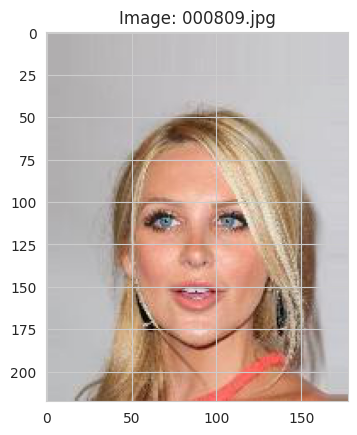

In [9]:
# Inspecting image path by visualizing
img_filename = df.iloc[random.randint(0, 1000)]['image_id']
img_path = os.path.join(img_dir, img_filename)

if os.path.exists(img_path):
    image = Image.open(img_path).convert('RGB')
    plt.imshow(image)
    plt.title(f"Image: {img_filename}")
    plt.show()
else:
    print(f"Images not found in path: {img_path}")

In [10]:
# Using a custom class to load image data.
class CelebADataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_names = os.listdir(img_dir)

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, idx):
        img_name = self.img_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image
    
# Setting custom transformation 
transform_WGAN = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])


In [11]:
# Creating the dataset and dataloader
dataset = CelebADataset(img_dir=img_dir, transform=transform_WGAN)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

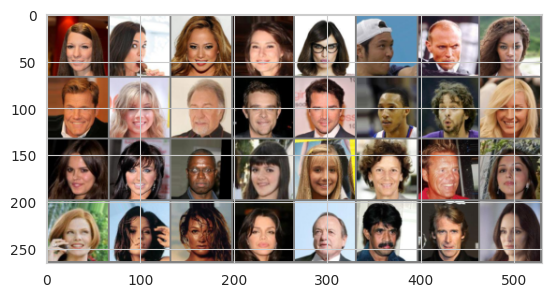

Batch shape: torch.Size([32, 3, 64, 64])


In [12]:
# Visualizing loaded and transformed images
def show_img(images):
    images=images/2+0.5 #Unnormalize for visualization
    npimg=images.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
    
dataiter = iter(dataloader)
images=next(dataiter)

show_img(torchvision.utils.make_grid(images))
print(f'Batch shape: {images.shape}')

<h2 id="architect-WGAN" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;">
  Wasstersteins GAN <strong>Architech</strong> setup
</h2>

In [18]:
# Generator
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d(100, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            # state size. 512 x 4 x 4
            
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # state size. 256 x 8 x 8
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # state size. 128 x 16 x 16
            
            nn.Upsample(scale_factor=2, mode='nearest'),  # Adding upsampling
            nn.Conv2d(128, 128, 3, 1, 1),  # Added convolutional layer
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # state size. 128 x 32 x 32
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # state size. 64 x 64 x 64
            
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. 3 x 128 x 128
        )

    def forward(self, input):
        return self.main(input)

netG = Generator().to(device)
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Upsample(scale_factor=2.0, mode='nearest')
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1),

In [19]:
# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # input is (nc) x 64 x 64
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. 64 x 32 x 32
            
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. 128 x 16 x 16
            
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. 256 x 8 x 8
            
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. 512 x 4 x 4
            
            nn.Conv2d(512, 1, 4, 1, 0, bias=False)
            # No sigmoid and no batch norm in the last layer for WGAN
        )

    def forward(self, input):
        return self.main(input)

netD = Discriminator().to(device)
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
  )
)


<h2 id="Training-WGAN" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;">
  Creating and running <strong>Training</strong> loop
</h2>

In [21]:
# Loss functions for Generator and Discriminator
def discriminator_loss(real_output, fake_output):
    return -torch.mean(real_output) + torch.mean(fake_output)

def generator_loss(fake_output):
    return -torch.mean(fake_output)

In [22]:
# Optimisers
lr_d = 0.000025
lr_g = 0.0001
optimizerD = optim.RMSprop(netD.parameters(), lr=lr_d)
optimizerG = optim.RMSprop(netG.parameters(), lr=lr_g)

# Loop parameters
num_epochs = 100
batch_size = 32
n_critic = 3  # Number of updates for the discriminator per generator update
clip_value = 0.01 

In [23]:
# Loop
for epoch in range(num_epochs):
    for i, real_images in enumerate(dataloader):
        # Train Discriminator
        for _ in range(n_critic):
            netD.zero_grad()
            real_images = real_images.to(device)
            batch_size = real_images.size(0)
            
            noise = torch.randn(batch_size, 100, 1, 1, device=device)
            fake_images = netG(noise)
            
            real_output = netD(real_images)
            fake_output = netD(fake_images.detach())
            d_loss = discriminator_loss(real_output, fake_output)
            d_loss.backward()
            optimizerD.step()
            
            # Clip weights of discriminator
            for p in netD.parameters():
                p.data.clamp_(-clip_value, clip_value)
        
        # Train Generator
        netG.zero_grad()
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        fake_images = netG(noise)
        fake_output = netD(fake_images)
        g_loss = -torch.mean(fake_output)
        g_loss.backward()
        optimizerG.step()

    print(f'Epoch [{epoch+1}/{num_epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}')

Epoch [1/100] | D Loss: -0.8675 | G Loss: 0.2170
Epoch [2/100] | D Loss: -0.8813 | G Loss: 0.2143
Epoch [3/100] | D Loss: -0.8772 | G Loss: 0.2275
Epoch [4/100] | D Loss: -0.8484 | G Loss: 0.2148
Epoch [5/100] | D Loss: -0.8730 | G Loss: 0.2209
Epoch [6/100] | D Loss: -0.8817 | G Loss: 0.2134
Epoch [7/100] | D Loss: -0.8807 | G Loss: 0.2162
Epoch [8/100] | D Loss: -0.8883 | G Loss: 0.2165
Epoch [9/100] | D Loss: -0.8879 | G Loss: 0.2194
Epoch [10/100] | D Loss: -0.8703 | G Loss: 0.2165
Epoch [11/100] | D Loss: -0.8879 | G Loss: 0.2164
Epoch [12/100] | D Loss: -0.8803 | G Loss: 0.2206
Epoch [13/100] | D Loss: -0.8753 | G Loss: 0.2126
Epoch [14/100] | D Loss: -0.8877 | G Loss: 0.2152
Epoch [15/100] | D Loss: -0.8827 | G Loss: 0.2176
Epoch [16/100] | D Loss: -0.8786 | G Loss: 0.2188
Epoch [17/100] | D Loss: -0.8873 | G Loss: 0.2209
Epoch [18/100] | D Loss: -0.8744 | G Loss: 0.2161
Epoch [19/100] | D Loss: -0.8795 | G Loss: 0.2188
Epoch [20/100] | D Loss: -0.8687 | G Loss: 0.2139
Epoch [21

<h2 id="Generating-saving" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;">
  <strong>Generating</strong>, <strong>Saving</strong> and <strong>Visualizing</strong> images
</h2>

In [25]:
# Generate and save images
num_samples = 100
noise = torch.randn(num_samples, 100, 1, 1, device=device)
fake_images = netG(noise)

# image_files = [os.path.join(gen_img_dir, img) for img in os.listdir(gen_img_dir) if img.endswith('.png')]
# print(f'{len(image_files)} images generated')

# # Naming and saving images
# for i  in range(num_samples):
#     save_image(fake_images[i], os.path.join(gen_img_dir, f'gen_{i}.png'))
# print('and saved successfully!')

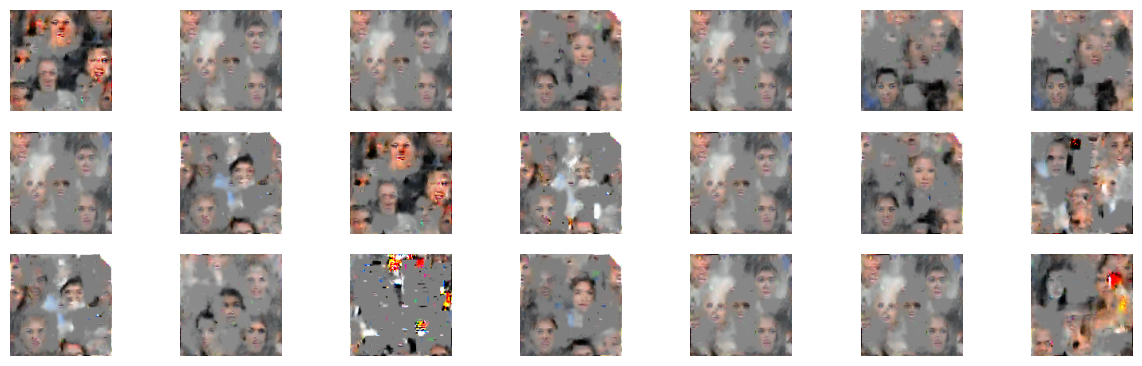

In [26]:
# # Visualizing generated images
num_imgs_to_display = 21
selected_indices = random.sample(range(fake_images.size(0)), num_imgs_to_display)

cols = 7
rows = (num_imgs_to_display + cols - 1) // cols

plt.figure(figsize=(15, 4.5))
for i, index in enumerate(selected_indices):
    image_tensor = fake_images[index]
    # Convert the tensor to a format suitable for displaying
    image_np = image_tensor.cpu().detach().numpy().transpose((1, 2, 0))
    image_np = (image_np - image_np.min()) / (image_np.max() - image_np.min())  # Normalize to 0-1 range
    plt.subplot(rows, cols, i+1)
    plt.imshow(image_np)
    plt.axis('off')
plt.show()

In [32]:
# Specify desired number of images to save
num_images_to_save = 15

# Specify directory
save_directory = '/scratch/xw97/jj7317/CelebA-CSV-files/Generated-images/'
if not os.path.exists(save_directory):
    os.makedirs(save_directory)

# Saving
for i in range(num_images_to_save):
    img_path = os.path.join(save_directory, f"gen-img-{i + 1}.png")
    save_image(fake_images[i], img_path)
print(f"{num_images_to_save} images saved successfully to {save_directory}")

15 images saved successfully to /scratch/xw97/jj7317/CelebA-CSV-files/Generated-images/


<h1 id="FID" align="center" style="color:white; background-color:#001344; padding:10px; border-bottom: 3px solid #460E54;"><strong>Fréchet Inception Distance</strong> score</h1> 

<h2 id="FID-Part-1" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;">
  <strong>Part 1:</strong> Preparing <strong>generated</strong> images for FID score
</h2>

<h3 id="FID-gen-transformation" align="left" style="color:black; background-color: white ; padding:10px; border-bottom: 0px solid #5f5b5a;">
  <strong>1.1 - </strong> Loading and transformation
</h3>

In [42]:
transform_fid_gen = transforms.Compose([
    transforms.Resize((299, 299)), # Recommended for InceptionV3
])

In [44]:
transformed_gen_images = torch.stack([transform_fid_gen(image) for image in fake_images])

print('Generated images tranformed successfully for Feature Extraction')

Generated images tranformed successfully for Feature Extraction


<h3 id="FID-gen-FE" align="left" style="color:black; background-color: white ; padding:10px; border-bottom: 0px solid #5f5b5a;">
  <strong>1.2 - </strong> Feature extraction
</h3>

In [45]:
# Initializing pre-trained InceptionV3 model
inception_model = models.inception_v3(pretrained=True, transform_input=False)
inception_model.fc = torch.nn.Identity()  # Removing the final fully connected layer
inception_model = inception_model.to(device)
inception_model.eval()  # Set the model to evaluation mode

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /home/576/jj7317/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100%|██████████| 104M/104M [01:28<00:00, 1.24MB/s] 


Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [46]:
with torch.no_grad():
    transformed_gen_images = transformed_gen_images.to(device)
    features = inception_model(transformed_gen_images)
    features_np = features.cpu().numpy()

In [55]:
def extract_features(image_tensor, model, device):
    model.eval()
    features = []
    with torch.no_grad():
        batch_size=32
        num_batches=len(image_tensor)//batch_size + (0 if len(image_tensor) % batch_size == 0 else 1)
        
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = start_idx + batch_size
            batch = image_tensor[start_idx:end_idx].to(device)
            output = model(batch)
            features.append(output.cpu().numpy())
    
    return np.concatenate(features)

In [56]:
# Extracting features of generated images
generated_img_ftrs = extract_features(transformed_gen_images, inception_model, device)
print("Extracted Features (Shape) of Generated images:", generated_img_ftrs.shape)
print("Extracted Features (Type) of Generated images:", generated_img_ftrs.dtype)

Extracted Features (Shape) of Generated images: (100, 2048)
Extracted Features (Type) of Generated images: float32


<h2 id="FID-Part-2" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;">
  <strong>Part 2:</strong> Preparing <strong>real</strong> images for FID score
</h2>

<h3 id="FID-real-transformation" align="left" style="color:black; background-color: white ; padding:10px; border-bottom: 0px solid #5f5b5a;">
  <strong>2.1 - </strong> Loading and transformation
</h3>

In [67]:
# Directory where the original images are stored
img_dir = job_fs + '/img_align_celeba/img_align_celeba'

# Directory where transformed images will be stored for feature extraction
real_img_dir_fid = job_fs + '/img_align_celeba_fid'

# Creating a subdirectory 'class0' in the new directory for ImageFolder
subdirectory_path_real = os.path.join(real_img_dir_fid, 'class0')
os.makedirs(subdirectory_path_real, exist_ok=True)

In [68]:
transform_fid_real = transforms.Compose([
    transforms.Resize((299, 299)), # Recommended for InceptionV3
    transforms.ToTensor()
])

In [69]:
# Link images to the new subdirectory if not already done
if not os.listdir(subdirectory_path_real):  # Check if directory is empty
    for filename in os.listdir(img_dir):
        original_file_path = os.path.join(img_dir, filename)
        new_file_path = os.path.join(subdirectory_path_real, filename)
        os.symlink(original_file_path, new_file_path)  # Creating a symbolic link

# Confirm the number of links created (Optional)
print("Number of symbolic links created:", len(os.listdir(subdirectory_path_real)))

Number of symbolic links created: 202599


In [70]:
dataset_real = datasets.ImageFolder(root=real_img_dir_fid, transform=transform_fid_real)
dataloader_real = DataLoader(dataset_real, batch_size=32, shuffle=False)  # No need to shuffle for feature extraction
print('Generated images tranformed successfully for Feature Extraction')

Generated images tranformed successfully for Feature Extraction


<h3 id="FID-real-FE" align="left" style="color:black; background-color: white ; padding:10px; border-bottom: 0px solid #5f5b5a;">
  <strong>2.2 - </strong> Feature extraction
</h3>

In [72]:
# Function to extract features from 'real' images
def extract_features(dataloader, model, device):
    model.eval()
    features = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            output = model(images)
            features.append(output.cpu().numpy())
    return np.concatenate(features)

In [73]:
# Extracting features of real images
real_img_features = extract_features(dataloader_real, inception_model, device)
print("Extracted Features (Shape) of Real images:", real_img_features.shape)
print("Extracted Features (Type) of Real images:", real_img_features.dtype)

Extracted Features (Shape) of Real images: (202599, 2048)
Extracted Features (Type) of Real images: float32


<h2 id="FID-Part-3" align="left" style="color:#5f5b5a; background-color: white ; padding:10px; border-bottom: 3px solid #5f5b5a;">
  <strong>Part 3:</strong> <strong>Calculating</strong> FID score
</h2>

In [74]:
# Function for FID calculation
def calculate_fid(real_img_features, generated_img_ftrs):
    # Calculating mean and covariance stats
    mu1, sigma1 = real_img_features.mean(axis=0), np.cov(real_img_features, rowvar=False)
    mu2, sigma2 = generated_img_ftrs.mean(axis=0), np.cov(generated_img_ftrs, rowvar=False)
    
    # Calculating sum of squared differences between means
    ssdiff = np.sum((mu1 - mu2) ** 2.0)
    
    # Calculating squareroot of product between cov
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    # FID
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

<u>Formula used</u>:

$$
\text{FID} = \|\mu_r - \mu_g\|^2 + \text{Tr}(\Sigma_r + \Sigma_g - 2(\Sigma_r \Sigma_g)^{1/2})
$$

Where:
- $\mu_r$ and $\mu_g$ are the ***feature-wise*** **mean vectors** of the **real** and **generated** images, respectively.
- $\Sigma_r$ and $\Sigma_g$ are the **covariance matrices** of the **features** of the **real** and **generated** images, respectively.
- $\text{Tr}$ denotes the trace of a matrix, which is the **sum of the elements on the main diagonal**.
- $(\Sigma_r \Sigma_g)^{1/2}$ is the **square root of the product of the covariance matrices**, computed as the **matrix square root of their product**.

In [76]:
# Getting the score
fid_score = calculate_fid(real_img_features, generated_img_ftrs)
print(f'Frechet Inception Distance score = {fid_score}')

Frechet Inception Distance score = 296.7699817350293
